## Example 2.1 - Use the Experiment Class to Normalize XANES

    In this example XAS data will be normalized in the Experiment Class object.

    This example assumes that you have previoudly run '2.0 Example - Experiment Class -  XAS Data Import and Calibration' and have a saved 'pickled' file.


### XAS processing steps: 
    1. Determine Suitable Energy Range for Normalization
    2. Perform Normalization
    3. Inspect Bulk Normalization of Spectra
    
### Workflow steps:
    
    1. Import Modules
    2. Define Paths
    3. Open Saved Experiment using 'pickle'
    4. Normalize Spectra

### Things to have ready when attemtping this example:

    1. Directory and filename for the 'pickled' experiment 
    2. Scan name of one spectra in the experiment object
    
    
## Step 1. Import Modules

In [1]:
# File Handling:
import os
import pickle

# Plot Things:
import matplotlib.pyplot as plt

# Make things interactive:
import ipywidgets as widgets
from ipywidgets import interact, fixed, GridspecLayout
from IPython.display import display

# catXAS:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp

# Plot Handling:
%matplotlib inline

In C:\Users\ashoff\.matplotlib\stylelib\mycustom.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\ashoff\.matplotlib\stylelib\mycustom.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\ashoff\.matplotlib\stylelib\scpy.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\ashoff\.matplotlib\stylelib\scpy.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


## Step 2. Define Paths

#### Modify:
    1. pickle_dir - directory containing the pickled experiment
    2. pickpe_name - filename of the pickled experiment (must include extension '.pickle')
    3. scan_name - a name of one fo the spectra in the experiment, used for interrogation throughout

In [2]:
# Directory Containing Experiment:
pickle_dir = os.path.join(pwd, 'sample results')

# Name of Experiment (must include extension '.pickle')
pickle_name = 'SnO2_TPR.pickle'

# Scan Naame for looking at parts of the Experiment Object
scan_name = '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0001'

## Step 3. Open Saved Experiment using 'pickle'

    Pickle - A method to save the experimental class and reopen it elsewhere.

In [3]:
pickle_path = os.path.join(pickle_dir,pickle_name)
pickle_in = open(pickle_path,"rb")
my_exp = pickle.load(pickle_in)
pickle_in.close()

## Step 4. Normalize Spectra

    Normalization using the same parameters as Athena.

### Major steps for normalization will:
    a. Scan the energy ranges of the data and suggest normalization parameters (spectra files need an E0 value)
    b. Set the normalization parameters
    c. Normalize the spectra

### 4a. Normalize the Reference Spectra
#### 4a-1. Inpsect the dataset to suggest a common set of normalization parameters

In [4]:
# Inspect each spectrum's energy range and suggest normalization paramters

df2 = my_exp.check_Energy_Range(has_e0 = True, spectra_name = 'mu Reference', print_summary = True)

Energy Range and Energy-Step Summary for mu Reference
	Variation in starting energy points between spectra [eV]: 29004.24-29004.75
	Variation in ending energy points between spectra [eV]: 30175.00-30175.45
	Variation in step size of energy points between spectra [eV]: 0.24-0.24

Normalization Parameters for mu Reference
	Edge Energy Range [E0]: 29200.00-29200.00 eV
	Pre-edge start/stop Suggestion [pre1/pre2]: -150/-50
	Post-edge start/stop Suggestion [norm1/norm2]: 75/700
	Normalizaion order Suggestion [nnorm]: 2
	Flatten Spectra Suggestion [make_norm]: True



#### 4a-2. Upload Normalization Parameters, Visualize Pre-edge and Normalization Lines and Normalzied Spectra

In [5]:
# Update values in the dictionary based upon summary results above

#Refernece Normalization paramters, referenced to E0
Ref_norm_params = {'pre1': -175,
                    'pre2': -100,
                    'norm1': 120,
                    'norm2': 950,
                    'nnorm': 2,
                    'make_flat': True
                   }

# Load Parameters into the reference sepctra
my_exp.load_params('mu Reference', Ref_norm_params)

# Perform specta normalization
my_exp.normalize_spectra('mu Reference')

# Check Normalization for each spectra
R_groups = []


for key in my_exp.spectra.keys():
    R_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Reference'])
    

interact(pfcts.plot_NormXANES,
         larch_group = R_groups)

interactive(children=(Dropdown(description='larch_group', options=(<Group '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tr…

<function plot.plot_NormXANES(larch_group)>

#### 4a-3. Inspection tools to show results of the spectra normalization
    1. Updated larch groups - experiment.spectra[scan_name]['Absorption Spectra']['mu Reference']
    2. Visualization of the normalized spectra

In [6]:
# 1. Inpsect updated 'mu Reference' group 

my_exp.spectra[scan_name]['Absorption Spectra']['mu Reference']

Attribute,Type,Value
energy,ndarray,"shape=(4839,), type=float64 range=[ 29004.2353: 30174.9982]"
mu,ndarray,"shape=(4839,), type=float64 range=[-0.14039600: 1.66162565]"
delE,float,1.0999999999985448
e0,float,29200.1048728863
pre1,int,-175
pre2,int,-100
norm1,int,120
norm2,int,950
nnorm,int,2
make_flat,bool,True


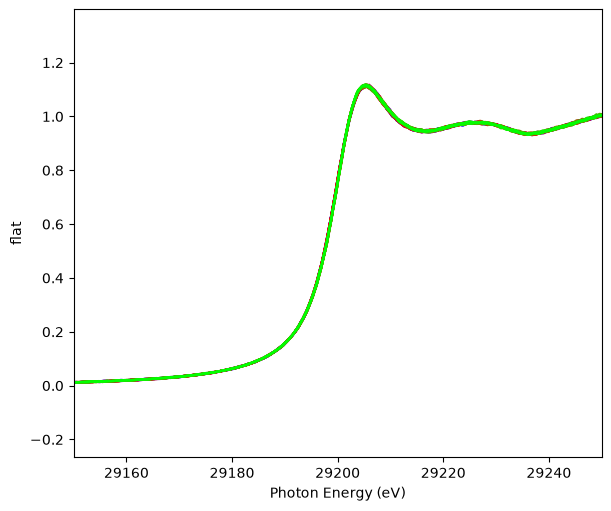

In [7]:
# 2. Visualization of Normalized Spectra - Reference
Edge_Energy = 29200 # eV

emin = Edge_Energy-50 # eV

emax = Edge_Energy+50 # eV

pfcts.plot_XANES(R_groups, emin, emax, spectra = 'flat', 
                 deriv = False, e0 = None, e0_line = False, 
                 overlay = True, use_legend = False)

### 4b. Normalize the Sample Spectra
#### 4b-1. Inpsect the dataset to suggest a common set of normalization parameters

In [8]:
# Inspect each spectrum's energy range and suggest normalization paramters

df2 = my_exp.check_Energy_Range(has_e0 = True, spectra_name = 'mu Sample', print_summary = True)

Energy Range and Energy-Step Summary for mu Sample
	Variation in starting energy points between spectra [eV]: 29004.24-29004.75
	Variation in ending energy points between spectra [eV]: 30175.00-30175.45
	Variation in step size of energy points between spectra [eV]: 0.24-0.24

Normalization Parameters for mu Sample
	Edge Energy Range [E0]: 29201.60-29201.60 eV
	Pre-edge start/stop Suggestion [pre1/pre2]: -150/-50
	Post-edge start/stop Suggestion [norm1/norm2]: 75/700
	Normalizaion order Suggestion [nnorm]: 2
	Flatten Spectra Suggestion [make_norm]: True



#### 4b-2. Upload Normalization Parameters, Visualize Pre-edge and Normalization Lines and Normalzied Spectra

In [9]:
# Update values in the dictionary based upon summary results above

#Refernece Normalization paramters, referenced to E0
Samp_norm_params = {'pre1': -175,
                    'pre2': -100,
                    'norm1': 120,
                    'norm2': 950,
                    'nnorm': 2,
                    'make_flat': True
                   }

# Load Parameters into the reference sepctra
my_exp.load_params('mu Sample', Samp_norm_params)

# Perform specta normalization
my_exp.normalize_spectra('mu Sample')

# Check Normalization for each spectra
S_groups = []


for key in my_exp.spectra.keys():
    S_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Sample'])
    

interact(pfcts.plot_NormXANES,
         larch_group = S_groups)

interactive(children=(Dropdown(description='larch_group', options=(<Group '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tr…

<function plot.plot_NormXANES(larch_group)>

#### 4b-3. Inspection tools to show results of the spectra normalization
    1. Updated larch groups - experiment.spectra[scan_name]['Absorption Spectra']['mu Sample']
    2. Visualization of the normalized spectra

In [11]:
# 1. Inpsect updated 'mu Reference' group 

my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample']

Attribute,Type,Value
energy,ndarray,"shape=(4839,), type=float64 range=[ 29004.2353: 30174.9982]"
mu,ndarray,"shape=(4839,), type=float64 range=[-0.94510060: 0.82209348]"
delE,float,1.0999999999985448
e0,float,29201.7285365002
pre1,int,-175
pre2,int,-100
norm1,int,120
norm2,int,950
nnorm,int,2
make_flat,bool,True


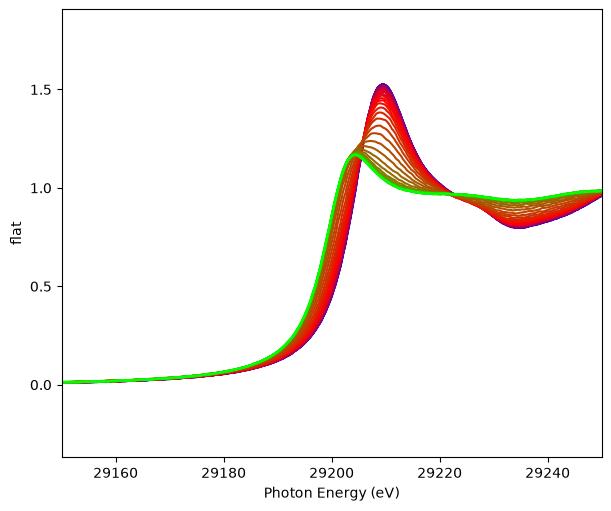

In [12]:
# 2. Visualization of Normalized Spectra - Reference
Edge_Energy = 29200 # eV

emin = Edge_Energy-50 # eV

emax = Edge_Energy+50 # eV

pfcts.plot_XANES(S_groups, emin, emax, spectra = 'flat', 
                 deriv = False, e0 = None, e0_line = False, 
                 overlay = True, use_legend = False)

## Step 5. Save Experiment with 'pickle' 
    Pickle - A method to save the experimental class and reopen it elsewhere.

In [10]:
pickle_out = open(pickle_path,"wb")
pickle.dump(my_exp, pickle_out)
pickle_out.close()